# Lab 7

Description of lab:

The basic math behind simple regression, how to compute a simple linear regression using python and statsmodels. Plotting regression lines over data. Understanding how standard errors represent uncertainty. How to make prediction estimates and prediction intervals. How to do a Monte Carlo 'fake data' simulation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

#new packages
import statsmodels as sms
import statsmodels.formula.api as smf
import seaborn as sns

from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

Create some data based on a linear relationship with an added noise which is normally distributed with mean 0 and standard deviation $\sigma$.

In [3]:
n = 100
x = np.linspace(0, 20, n)
sigma = 4
a = .4
b = .8
epsilon = spt.norm.rvs(0, sigma, n, random_state = 1234)
y = a + b * x + epsilon

In [5]:
fakeDF = pd.DataFrame({'x': x, 'y': y})
fakeDF.head()

,x,y
0,0.000000,2.285741
1,0.202020,-4.202287
2,0.404040,6.454060
3,0.606061,-0.365759
4,0.808081,-1.835890


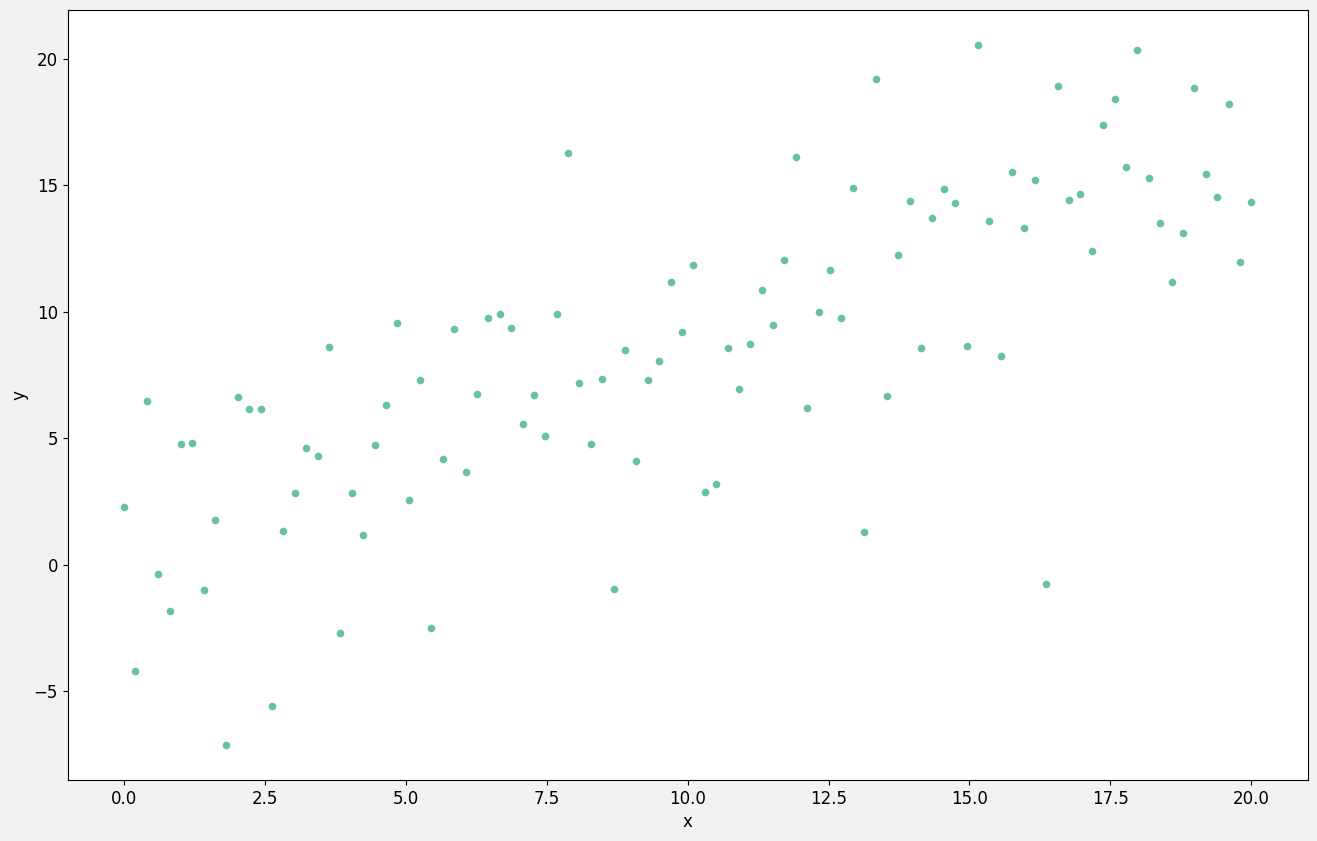

In [7]:
fig, ax = plt.subplots()
fakeDF.plot.scatter(x = 'x', y = 'y', ax = ax)
plt.show()

In [9]:
# Estimate a and b using ols in statsmodels:
mod1 = smf.ols(formula = 'y ~ x', data = fakeDF).fit()

In [10]:
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     129.9
Date:                Sun, 03 Dec 2023   Prob (F-statistic):           1.15e-19
Time:                        19:00:50   Log-Likelihood:                -280.07
No. Observations:                 100   AIC:                             564.1
Df Residuals:                      98   BIC:                             569.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6782      0.798      0.849      0.398      -0.906       2.263
x              0.7862      0.069     11.398      0.000       0.649       0.923
==============================================================================
Omnibus:                       10.734   Durbin-Watson:                   2.430
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               11.741
Skew:                          -0.640   Prob(JB):                      0.00282
Kurtosis:                       4.086   Cond. No.                         23.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
# Estimating the standard deviation of the model:
np.sqrt(mod1.mse_resid)

4.022355463666853

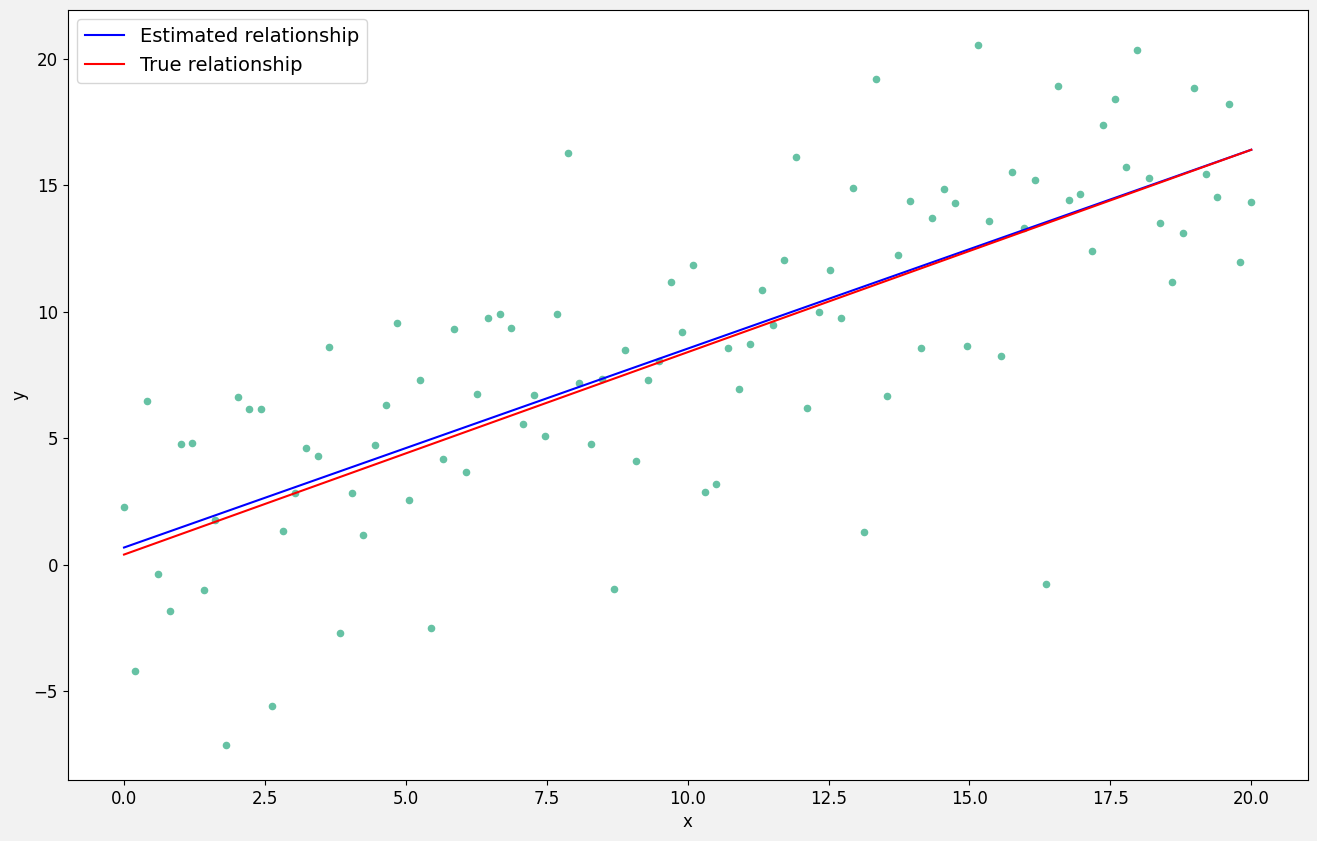

In [13]:
# Plotting the regression line:
a_hat = mod1.params.iloc[0]
b_hat = mod1.params.iloc[1]

fig, ax = plt.subplots()
fakeDF.plot.scatter(x = 'x', y = 'y', ax = ax)
ax.plot(fakeDF['x'], a_hat + b_hat * fakeDF['x'], color = 'blue', label = 'Estimated relationship')
ax.plot(fakeDF['x'], a + b * fakeDF['x'], color = 'red', label = 'True relationship')
plt.legend()
plt.show()

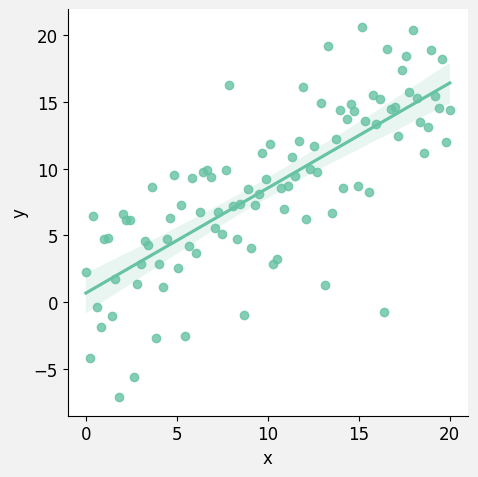

In [14]:
# Default command in seaborn for plotting the regression line:
sns.lmplot(x = 'x', y = 'y', data = fakeDF)
plt.show()

### Regression to the mean and mistaken interpretation: A simulation.

In [15]:
# Can a midterm result affect the exam score:
n = 1000
true_ability = spt.norm.rvs(50, 10, n, random_state = 1234)
noise1 = spt.norm.rvs(0, 10, n)
noise2 = spt.norm.rvs(0, 10, n)
midterm = true_ability + noise1
final = true_ability + noise2
exams = pd.DataFrame({'midterm': midterm, 'final': final})

In [16]:
mod2 = smf.ols(formula = 'final ~ midterm', data = exams).fit()
mod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  final   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     329.0
Date:                Sun, 03 Dec 2023   Prob (F-statistic):           9.01e-64
Time:                        19:37:05   Log-Likelihood:                -3895.1
No. Observations:                1000   AIC:                             7794.
Df Residuals:                     998   BIC:                             7804.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.1599      1.438     17.492      0.000      22.337      27.982
midterm        0.4957      0.027     18.139      0.000       0.442       0.549
==============================================================================
Omnibus:                        3.744   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.154   Jarque-Bera (JB):                3.814
Skew:                           0.145   Prob(JB):                        0.149
Kurtosis:                       2.914   Cond. No.                         201.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

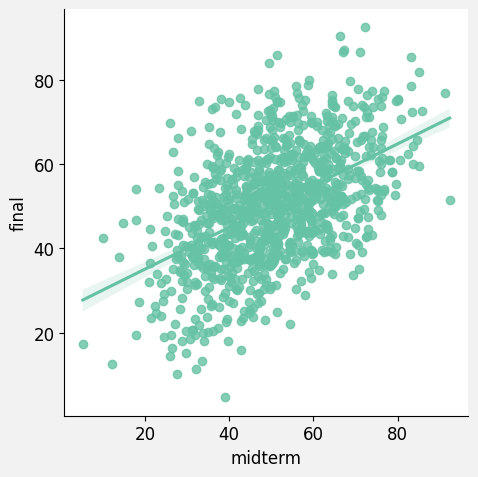

In [18]:
sns.lmplot(x = 'midterm', y = 'final', data = exams)
plt.show()

### Regression with a single predictor: real data.

In [19]:
pwt = pd.read_csv("http://jmaurit.github.io/anv_statistikk/data/pwt2019plus.csv")
pwt.head()

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k,type,cases,rgdpe_per_pers,cases_per_pers
0,AGO,Angola,Kwanza,2019,228151.01560,227855.71880,31.825295,16.644962,NaN,1.481984,...,0.342872,0.240024,0.476486,0.611627,0.209101,0.378033,confirmed,97263.0,7168.857841,0.003056
1,ALB,Albania,Lek,2019,35890.01953,36103.04297,2.880917,1.075898,NaN,2.964992,...,0.456882,0.235589,0.629832,0.525463,0.299344,NaN,confirmed,248070.0,12457.845724,0.086108
2,ARE,United Arab Emirates,UAE Dirham,2019,681525.81250,645956.25000,9.770529,5.808834,NaN,2.746695,...,0.480580,0.692488,0.688882,0.647336,0.268754,NaN,confirmed,828328.0,69753.215256,0.084778
3,ARG,Argentina,Argentine Peso,2019,991646.31250,977420.56250,44.780677,20.643215,1609.068998,3.096804,...,0.616060,0.312739,0.647736,0.631130,0.377946,0.758450,confirmed,7940657.0,22144.513637,0.177323
4,ARM,Armenia,Armenian Dram,2019,41048.62891,43582.57422,2.957731,0.966091,NaN,3.135995,...,0.577787,0.176624,0.666217,0.587048,0.432372,0.617077,confirmed,352399.0,13878.418595,0.119145


In [20]:
# Tranform both rGDP and cases per person to log:
pwt['log_rgdp'] = np.log(pwt['rgdpe_per_pers'])
pwt['log_cases'] = np.log(pwt['cases_per_pers'])

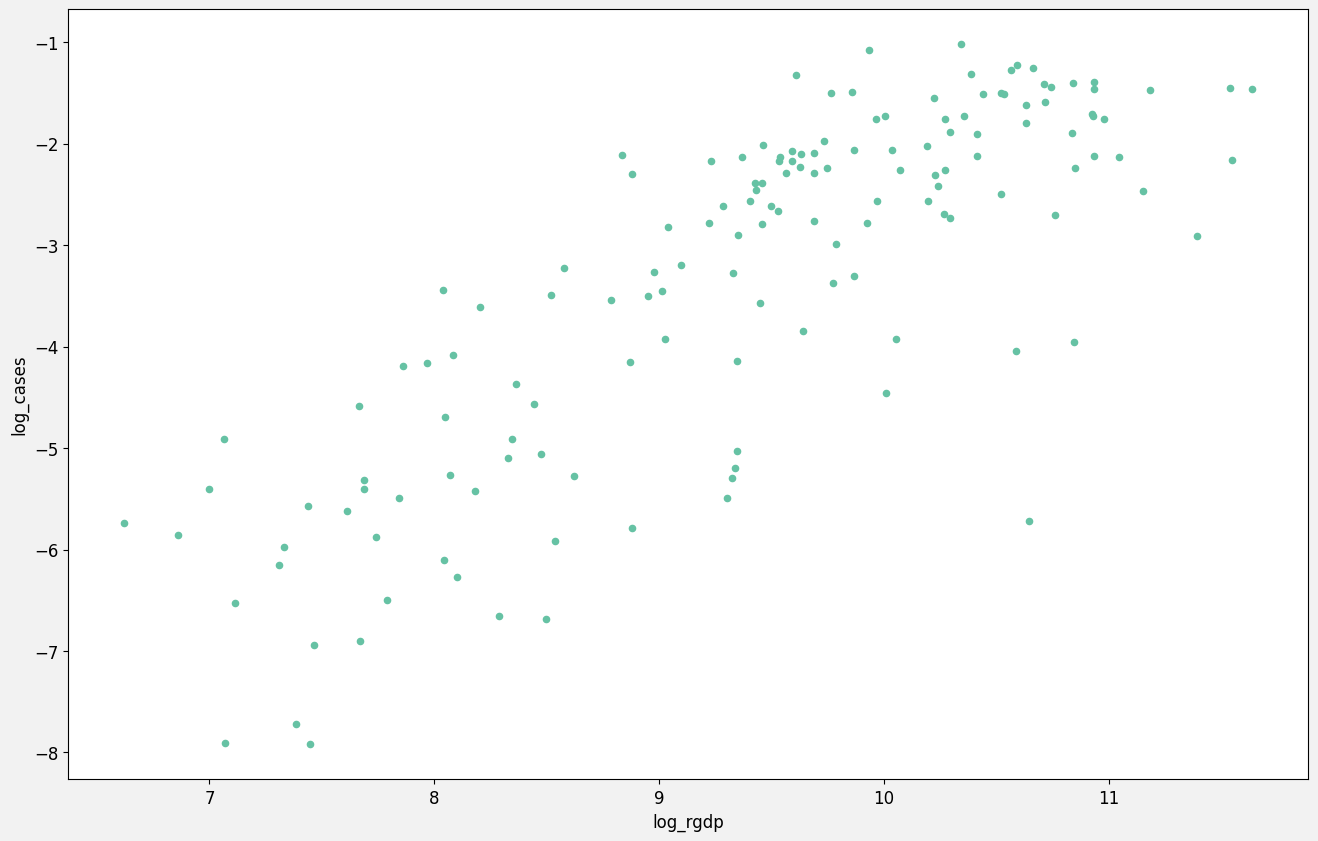

In [21]:
pwt.plot.scatter('log_rgdp', 'log_cases')
plt.show()

In [22]:
mod3 = smf.ols(formula = 'log_cases ~ log_rgdp', data = pwt).fit()
mod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_cases   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     268.7
Date:                Sun, 03 Dec 2023   Prob (F-statistic):           6.57e-35
Time:                        19:43:51   Log-Likelihood:                -212.89
No. Observations:                 148   AIC:                             429.8
Df Residuals:                     146   BIC:                             435.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -14.4496      0.684    -21.119      0.000     -15.802     -13.097
log_rgdp       1.1823      0.072     16.391      0.000       1.040       1.325
==============================================================================
Omnibus:                       17.372   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.615
Skew:                          -0.845   Prob(JB):                     5.50e-05
Kurtosis:                       3.568   Cond. No.                         77.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

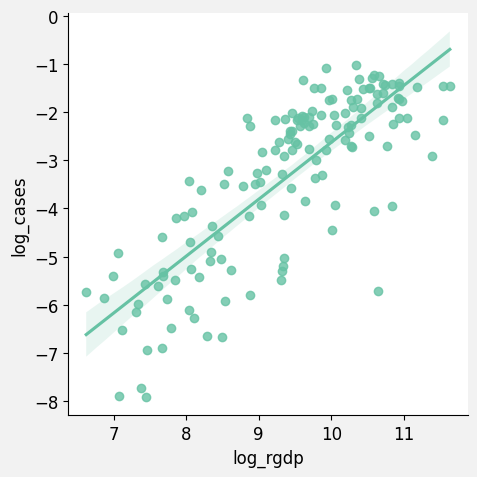

In [23]:
sns.lmplot(x = 'log_rgdp', y = 'log_cases', data = pwt)
plt.show()

In [24]:
# Residual standard deviation (estimate of the models standard deviation):
np.sqrt(mod3.mse_resid)

1.0266877793405222

##### Prediction

In [25]:
# Predict the cases per capita in Norway:
norway_rgdp = pwt['log_rgdp'].loc[pwt['country'] == 'Norway']

norway_pred = mod3.predict(norway_rgdp)
norway_pred

105   -1.392514
dtype: float64

In [27]:
# Alternatively:
norway_prediction = mod3.get_prediction(norway_rgdp)
pred_CI = norway_prediction.conf_int()
pred_CI

array([[-1.67860241, -1.10642594]])

In [28]:
# Converting back to cases per capita:
np.exp(norway_pred)

105    0.24845
dtype: float64

In [29]:
np.exp(pred_CI)

array([[0.18663463, 0.33073893]])

In [31]:
# Actual cases per capita
np.exp(pwt['log_cases'].loc[pwt['country'] == 'Norway'])

105    0.119196
Name: log_cases, dtype: float64

##### Causality
Cases per capita and real gdp per capita seem to be related, but this does not infer a causal relationship. Higher GDP does not necessarily cause higher COVID cases per capita. Possible explainations are: Lurking or missig variable (some other variable may explain the relationship between these which could cause them to seem correlated, age perhaps), or measurement problems and data collection (Richer countries may be more enept to collect data on cases, where poorer countries might be lacking in resources to register all data).

##### Inference on means and differences using regression

In [32]:
mod4 = smf.ols(formula = 'cases_per_pers ~ 1', data = pwt).fit()
mod4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         cases_per_pers   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 03 Dec 2023   Prob (F-statistic):                nan
Time:                        20:08:15   Log-Likelihood:                 151.83
No. Observations:                 148   AIC:                            -301.7
Df Residuals:                     147   BIC:                            -298.7
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0888      0.007     12.415      0.000       0.075       0.103
==============================================================================
Omnibus:                       17.633   Durbin-Watson:                   1.818
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.123
Skew:                           0.925   Prob(JB):                     2.59e-05
Kurtosis:                       3.005   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
# Calculate the mean value for Nordic countries:
Nordics = ['Sweden', 'Norway', 'Finland', 'Denmark', 'Iceland']
pwt['nordic'] = np.where(pwt['country'].isin(Nordics), 1, 0)

In [35]:
mod5 = smf.ols(formula = 'cases_per_pers ~ nordic', data = pwt).fit()
mod5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         cases_per_pers   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     3.234
Date:                Sun, 03 Dec 2023   Prob (F-statistic):             0.0742
Time:                        20:11:53   Log-Likelihood:                 153.45
No. Observations:                 148   AIC:                            -302.9
Df Residuals:                     146   BIC:                            -296.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0864      0.007     11.965      0.000       0.072       0.101
nordic         0.0707      0.039      1.798      0.074      -0.007       0.148
==============================================================================
Omnibus:                       19.670   Durbin-Watson:                   1.856
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.877
Skew:                           0.980   Prob(JB):                     6.54e-06
Kurtosis:                       3.165   Cond. No.                         5.54
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Monte Carlo fake data simulation
Creating fake data from a 'true' model and then do a regression on that data to see if we are estimating what we think we are estimating.

In [36]:
# Assuming that the estimated model for COVID cases on GDP is the true model, create data based on this:
a = -14.5
b = 1.18
n = 150
sigma = 1.02
x = np.linspace(6.5, 11.5, n)
epsilon = spt.norm.rvs(0, sigma, n, random_state = 1234)

y = a + b * x + epsilon

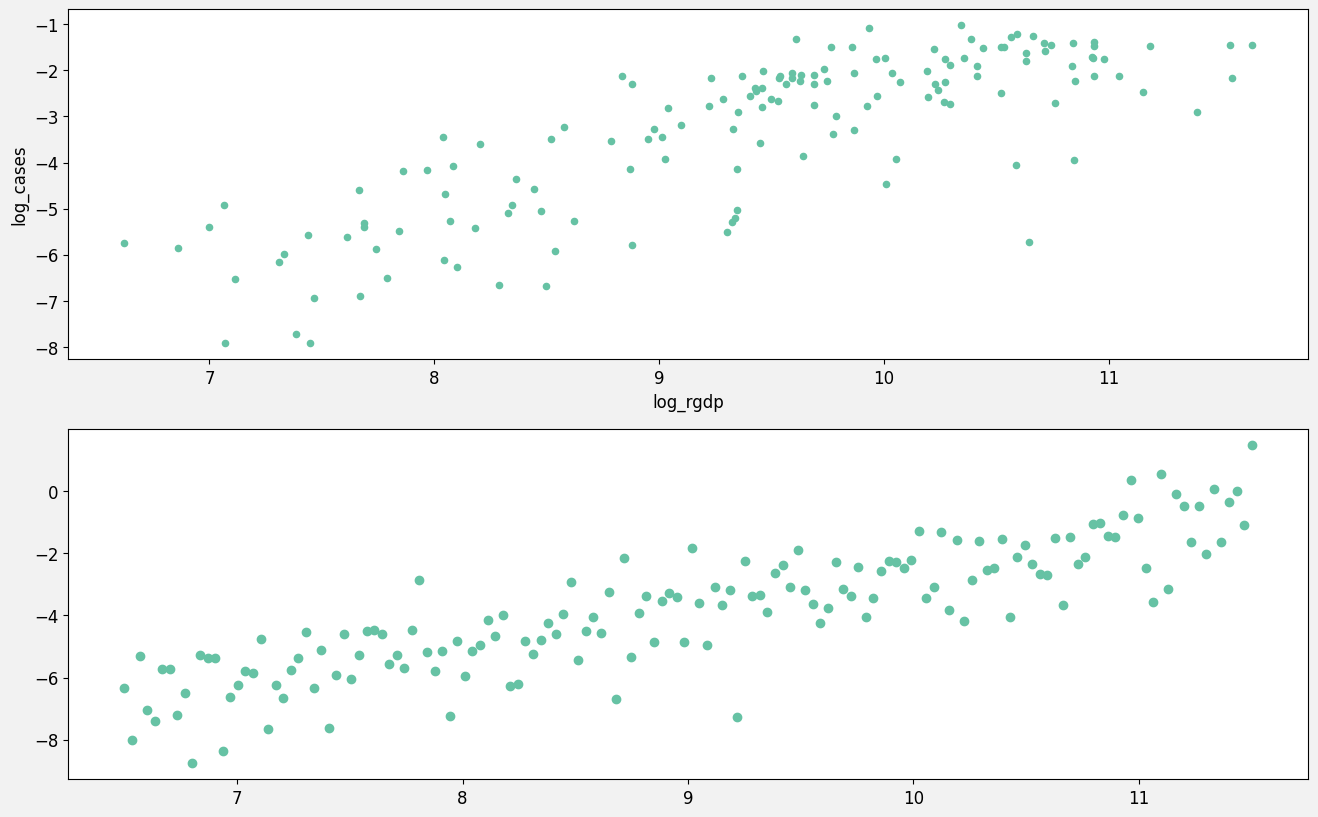

In [37]:
fig, ax = plt.subplots(2)
pwt.plot.scatter('log_rgdp', 'log_cases', ax = ax[0])
ax[1].scatter(x, y)
plt.show()

In [38]:
fakeDF = pd.DataFrame({'x': x, 'y': y})

mod5 = smf.ols(formula = 'y ~ x', data = fakeDF).fit()
mod5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     441.9
Date:                Sun, 03 Dec 2023   Prob (F-statistic):           2.76e-46
Time:                        20:23:58   Log-Likelihood:                -214.87
No. Observations:                 150   AIC:                             433.7
Df Residuals:                     148   BIC:                             439.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -14.6657      0.523    -28.055      0.000     -15.699     -13.633
x              1.2054      0.057     21.021      0.000       1.092       1.319
==============================================================================
Omnibus:                        9.308   Durbin-Watson:                   2.439
Prob(Omnibus):                  0.010   Jarque-Bera (JB):                9.526
Skew:                          -0.511   Prob(JB):                      0.00854
Kurtosis:                       3.691   Cond. No.                         57.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
# Defining the estimated b and generating the covariance for getting the standard error of b:
b_hat = mod5.params.iloc[1]

cov_b = mod5.cov_params()
cov_b

,Intercept,x
Intercept,0.273273,-0.029592
x,-0.029592,0.003288


In [41]:
SE_b = np.sqrt(cov_b.iloc[1, 1])
SE_b

0.057341411557687585

In [42]:
CI_min = b_hat - 2 * SE_b
CI_max = b_hat + 2 * SE_b

# Confidence interval to see wether it includes the true value:
[CI_min, CI_max]

[1.0906812113778799, 1.3200468576086302]

In [46]:
# Checking with python booleans
bool((b > CI_min) & (b < CI_max))

True

In [50]:
# Performing a monte carlo simulation to figure out whether the correct values will be estimated on average, and how correct the uncertainty approximations are.
nsim = 10000
b_hats = []
cover_95 = []

for s in range(nsim):
    epsilon = spt.norm.rvs(0, sigma, n) # Generating new epsilons for every loop. Creating new data every loop.
    y = a + b * x + epsilon
    fakeDF = pd.DataFrame({'x': x, 'y': y})
    mod6 = smf.ols(formula = 'y ~ x', data = fakeDF).fit()
    b_hat = mod6.params.iloc[1]
    b_hats.append(b_hat) # Save the estimated b in a list.
    CI_b = mod6.conf_int().iloc[1, :] # Shortcut for getting the confidence interval directly from the model.
    cover_95.append(int((b > CI_b[0]) & (b < CI_b[1])))

In [51]:
cover_95 = np.array(cover_95)
cover_95.mean()

0.9509

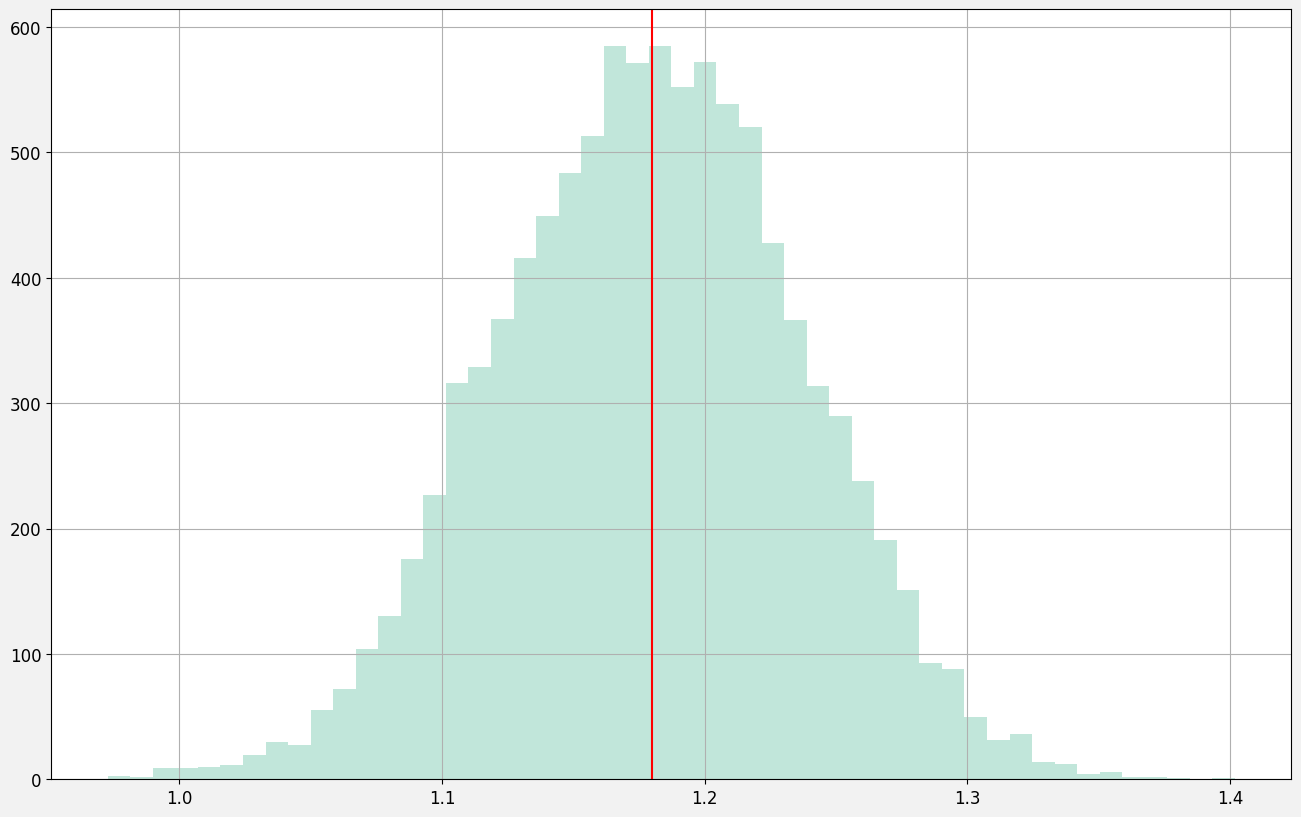

In [52]:
b_hats = pd.Series(b_hats)

fig, ax = plt.subplots()
b_hats.hist(ax = ax, bins = 50, alpha = .4)
ax.axvline(x = b, color = 'red')
plt.show()

### Ordinary Least Squares (OLS)

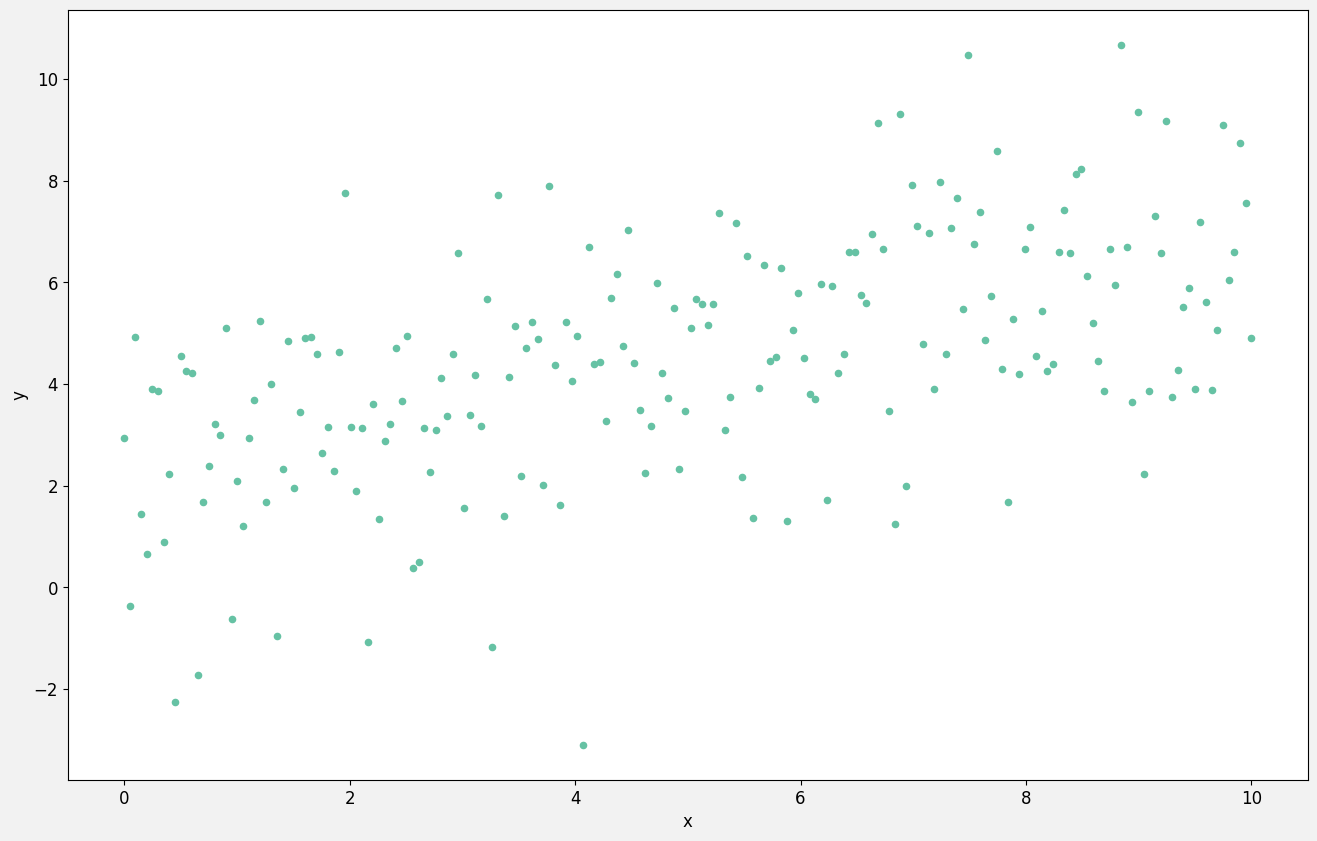

In [53]:
# Create some more fake data:
a = 2
b = .5
n = 200
sigma = 2
x = np.linspace(0, 10, n)
epsilon = spt.norm.rvs(0, sigma, n, random_state = 1234)

y = a + b * x + epsilon

fakeDF = pd.DataFrame({'x': x, 'y': y})
fakeDF.plot.scatter(x = 'x', y = 'y')
plt.show()

In [55]:
a_guess = 1
b_guess = .3

# Estimate residual sum of squares
y_guess = a_guess + b_guess * x

residuals = y - y_guess

RSS = np.sum(residuals ** 2)
RSS

1601.5898508201535

In [56]:
# The estimated a and b that minimize RSS are:
b_hat = np.cov(x, y, ddof = 1)[0, 1] / np.var(x, ddof = 1)
a_hat = np.mean(y) - b_hat * np.mean(x)

print(a_hat, b_hat)

2.2433519060076037 0.4483212507972465


In [58]:
# Estimate the residual standard deviation:
y_hat = a_hat + b_hat * x
sigma_hat = np.sqrt(np.sum((y - y_hat) ** 2) / n - 2) # n - 2 degrees of freedom.
sigma_hat

1.3721229050921124

##### Maximum Likelihood

In [60]:
ML_mod1 = smf.glm(formula = 'y ~ x', data = fakeDF).fit() # Generalized Linear Model
ML_mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      198
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          3.9219
Method:                          IRLS   Log-Likelihood:                -419.44
Date:                Sun, 03 Dec 2023   Deviance:                       776.54
Time:                        21:04:20   Pearson chi2:                     777.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.3504
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.2434      0.279      8.040      0.000       1.696       2.790
x              0.4483      0.048      9.288      0.000       0.354       0.543
==============================================================================
"""